In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, recall_score, 
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
import time

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas.")

✅ Librerías cargadas.


In [2]:
# 1. Cargar tus CSVs limpios
folder = ''
df_bin = pd.read_csv('csv/label1_10s.csv')
df_8 = pd.read_csv('csv/label2_10s.csv')
df_60 = pd.read_csv('csv/label3_10s.csv')
#le_df_bin = joblib.load('csv/le/le_label1_1sec.csv')
#le_df_8 = joblib.load('csv/le/le_label2_1sec.csv')
#le_df_60 = joblib.load('csv/le/le_label3_1sec.csv')

# 2. Definir columna objetivo
target_col = 'target' 

# 3. Extraer características (X) - Tomamos las del binario como base
X_all = df_bin.drop(columns=[target_col])
feature_names = X_all.columns.tolist()

# 4. Asegurar que todas las DataFrames tengan el mismo número de filas
min_len = min(len(df_bin), len(df_8), len(df_60))
df_bin = df_bin.iloc[:min_len].reset_index(drop=True)
df_8 = df_8.iloc[:min_len].reset_index(drop=True)
df_60 = df_60.iloc[:min_len].reset_index(drop=True)
X_all = X_all.iloc[:min_len].reset_index(drop=True)

# 5. Generar sets de TEST (usando el mismo random_state que en entrenamiento)
# Esto garantiza que evaluamos exactamente las mismas filas en las 3 tareas
indices = range(len(df_bin))
_, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_test_raw = X_all.iloc[test_idx]
y_test_bin = df_bin[target_col].iloc[test_idx]
y_test_8 = df_8[target_col].iloc[test_idx]
y_test_60 = df_60[target_col].iloc[test_idx]

print(f"✅ Datos listos. Muestras de test: {len(X_test_raw)}")

✅ Datos listos. Muestras de test: 6006


In [3]:
classes_8 = ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']
classes_60 = ['ack-frag-flood-port-1883', 'ack-frag-flood-port-80', 'arp-spoofing',
 'backdoor-upload', 'benign', 'command-injection', 'connect-flood',
 'dictionary-ssh', 'dictionary-telnet', 'host-disc-arp-ping',
 'host-disc-tcp-ack-ping', 'host-disc-tcp-syn-ping',
 'host-disc-tcp-syn-stealth', 'host-disc-udp-ping', 'http-flood-port-1883',
 'http-flood-port-443', 'http-flood-port-554', 'http-flood-port-6668',
 'http-flood-port-80', 'http-flood-port-9595', 'icmp-flood',
 'icmp-frag-flood', 'impersonation', 'ip-spoofing', 'mirai-syn-flood',
 'mirai-udp-flood', 'mqtt-publish-flood', 'os-scan', 'ping-sweep', 'port-scan',
 'push-ack-flood-port-1883', 'push-ack-flood-port-80',
 'rst-fin-flood-port-1883', 'rst-fin-flood-port-80', 'slowloris-port-1883',
 'slowloris-port-554', 'slowloris-port-80', 'slowloris-port-8000',
 'sql-injection', 'sql-injection-blind', 'syn-flood-port-1883',
 'syn-flood-port-22', 'syn-flood-port-23', 'syn-flood-port-443',
 'syn-flood-port-554', 'syn-flood-port-557', 'syn-flood-port-80',
 'synonymousip-flood-port-1883', 'synonymousip-flood-port-80',
 'tcp-flood-port-1883', 'tcp-flood-port-22', 'tcp-flood-port-23',
 'tcp-flood-port-443', 'tcp-flood-port-554', 'tcp-flood-port-80', 'udp-flood',
 'udp-flood-port-1883', 'udp-flood-port-80', 'udp-frag-flood', 'vuln-scan',
 'xss']

# Configuración de diccionarios
tareas = {
    "Binaria": {"prefix": "2clases", "y_real": y_test_bin, "classes" : ["attack", "benign"]},
    "8-Clases": {"prefix": "8clases", "y_real": y_test_8, "classes" : classes_8},
    "60-Clases": {"prefix": "60clases", "y_real": y_test_60, "classes" : classes_60}
}
algoritmos = ["RandomForest", "kNN", "MLP", "NaiveBayes"]

scalers = {}
modelos = {t: {} for t in tareas}
folder = 'joblibs/06042026-DefaultCIC-10sec-Optuna'

# Bucle de carga (Ajusta los nombres si tus archivos se llaman distinto)
for t, info in tareas.items():
    pfx = info["prefix"]
    scalers[t] = joblib.load(f"{folder}/{pfx}/scaler_final.joblib")
    
    for alg in algoritmos:
        path = f"{folder}/{pfx}/{alg}.joblib"
        if os.path.exists(path):
            modelos[t][alg] = joblib.load(path)
        else:
            print(f"⚠️ No se encontró: {path}")

print("✅ Modelos y Scalers cargados en memoria.")

✅ Modelos y Scalers cargados en memoria.


In [4]:
resultados_master = []

for t, info in tareas.items():
    # 1. Aplicar el scaler específico de la tarea
    X_test_scaled = scalers[t].transform(X_test_raw)
    
    for alg, modelo in modelos[t].items():
        # 2. Predicción
        start = time.time()
        y_pred = modelo.predict(X_test_scaled)
        end = time.time()
        
        # 3. Cálculo de métricas
        resultados_master.append({
            "Tarea": t,
            "Algoritmo": alg,
            "Accuracy": accuracy_score(info["y_real"], y_pred),
            "F1-Score": f1_score(info["y_real"], y_pred, average='macro'),
            "Recall": recall_score(info["y_real"], y_pred, average='macro'),
            "Tiempo de test": (end - start)
        })

df_comparativa = pd.DataFrame(resultados_master)
display(df_comparativa.sort_values(by=["Tarea", "F1-Score"], ascending=[True, False]))

/home/misaz/Uni/4/TFG/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Tarea,Algoritmo,Accuracy,F1-Score,Recall,Tiempo de test
9,60-Clases,kNN,0.869963,0.831171,0.826545,0.135467
10,60-Clases,MLP,0.820346,0.736874,0.734216,0.030358
8,60-Clases,RandomForest,0.726773,0.474908,0.467904,0.257425
11,60-Clases,NaiveBayes,0.137363,0.064375,0.122683,0.013170
6,8-Clases,MLP,0.965534,0.953543,0.936978,0.059808
5,8-Clases,kNN,0.952214,0.934081,0.917546,0.151585
4,8-Clases,RandomForest,0.802864,0.693592,0.710145,0.122129
7,8-Clases,NaiveBayes,0.137196,0.058976,0.163002,0.001771
2,Binaria,MLP,0.975857,0.975778,0.976752,0.066451
1,Binaria,kNN,0.971695,0.971616,0.972915,0.145551


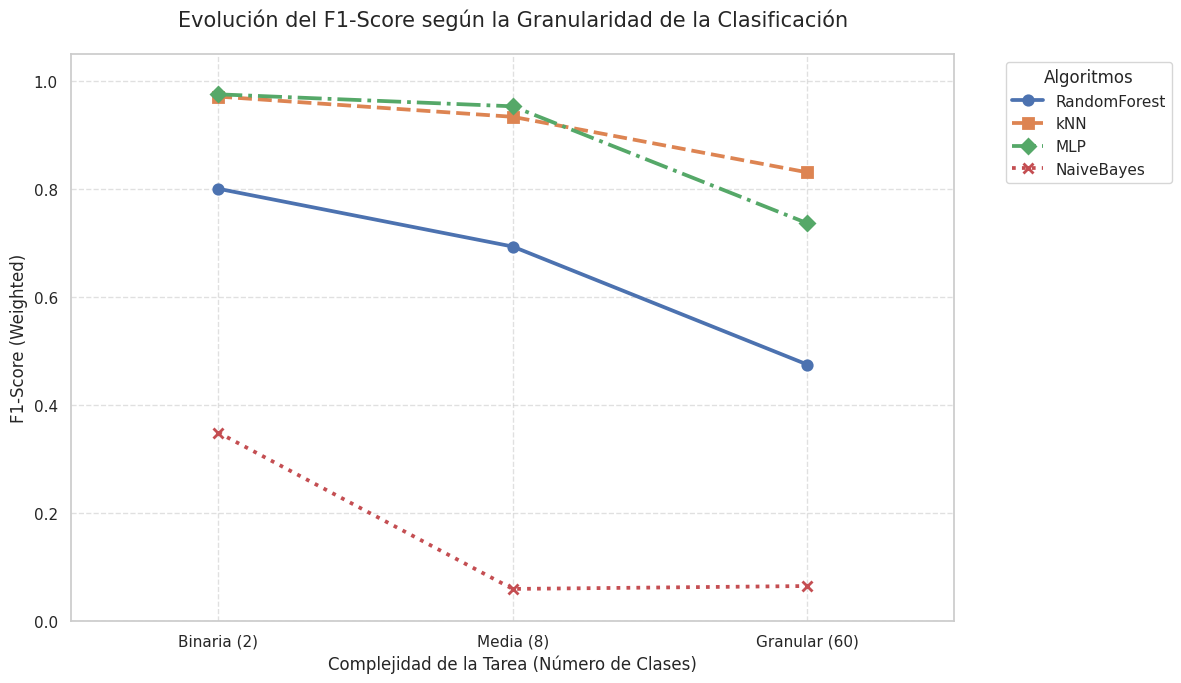

In [5]:
df_plot = df_comparativa.copy()

# Limpiamos los nombres de las tareas para que el orden sea natural
# (Quitamos los números que puso Pandas en el índice si es necesario)
mapeo_tareas = {
    "Binaria": "Binaria (2)",
    "8-Clases": "Media (8)",
    "60-Clases": "Granular (60)"
}
df_plot['Tarea_Limpia'] = df_plot['Tarea'].map(mapeo_tareas)

# 2. Configuración de la gráfica
plt.figure(figsize=(12, 7))

# Usamos pointplot para ver la tendencia (líneas que conectan los puntos)
sns.pointplot(
    data=df_plot, 
    x="Tarea_Limpia", 
    y="F1-Score", 
    hue="Algoritmo",
    markers=["o", "s", "D", "x"], # Diferentes formas para cada algoritmo
    linestyles=["-", "--", "-.", ":"],
    order=["Binaria (2)", "Media (8)", "Granular (60)"] # Forzamos el orden de complejidad
)

# 3. Estética profesional para el TFG
plt.title("Evolución del F1-Score según la Granularidad de la Clasificación", fontsize=15, pad=20)
plt.xlabel("Complejidad de la Tarea (Número de Clases)", fontsize=12)
plt.ylabel("F1-Score (Weighted)", fontsize=12)
plt.ylim(0, 1.05) # El límite superior un poco más de 1 para que no se corte el punto
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Algoritmos", bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadimos una anotación sobre Naive Bayes para la discusión
"""plt.annotate('Fuerte caída por asunción\nde independencia', 
             xy=(2, 0.08), xytext=(1.5, 0.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))"""

plt.tight_layout()
plt.show()

=== RESUMEN DE HIPERPARÁMETROS POR MODELO ===


,Tarea,Algoritmo,Params
0,Binaria,RandomForest,"{'max_depth': 20, 'n_estimators': 300}"
1,Binaria,kNN,"{'n_neighbors': 5, 'weights': 'distance'}"
2,Binaria,MLP,"{'activation': 'relu', 'alpha': 0.001306962296..."
3,Binaria,NaiveBayes,{'var_smoothing': 1e-09}
4,8-Clases,RandomForest,"{'max_depth': 20, 'n_estimators': 300}"
5,8-Clases,kNN,"{'n_neighbors': 5, 'weights': 'distance'}"
6,8-Clases,MLP,"{'activation': 'relu', 'alpha': 0.000497849415..."
7,8-Clases,NaiveBayes,{'var_smoothing': 1e-08}
8,60-Clases,RandomForest,"{'max_depth': 20, 'n_estimators': 300}"
9,60-Clases,kNN,"{'n_neighbors': 3, 'weights': 'distance'}"



=== IMPORTANCIA DE CARACTERÍSTICAS (Basado en RandomForest) ===


/tmp/ipykernel_2454/2376518610.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")
/tmp/ipykernel_2454/2376518610.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")
/tmp/ipykernel_2454/2376518610.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")


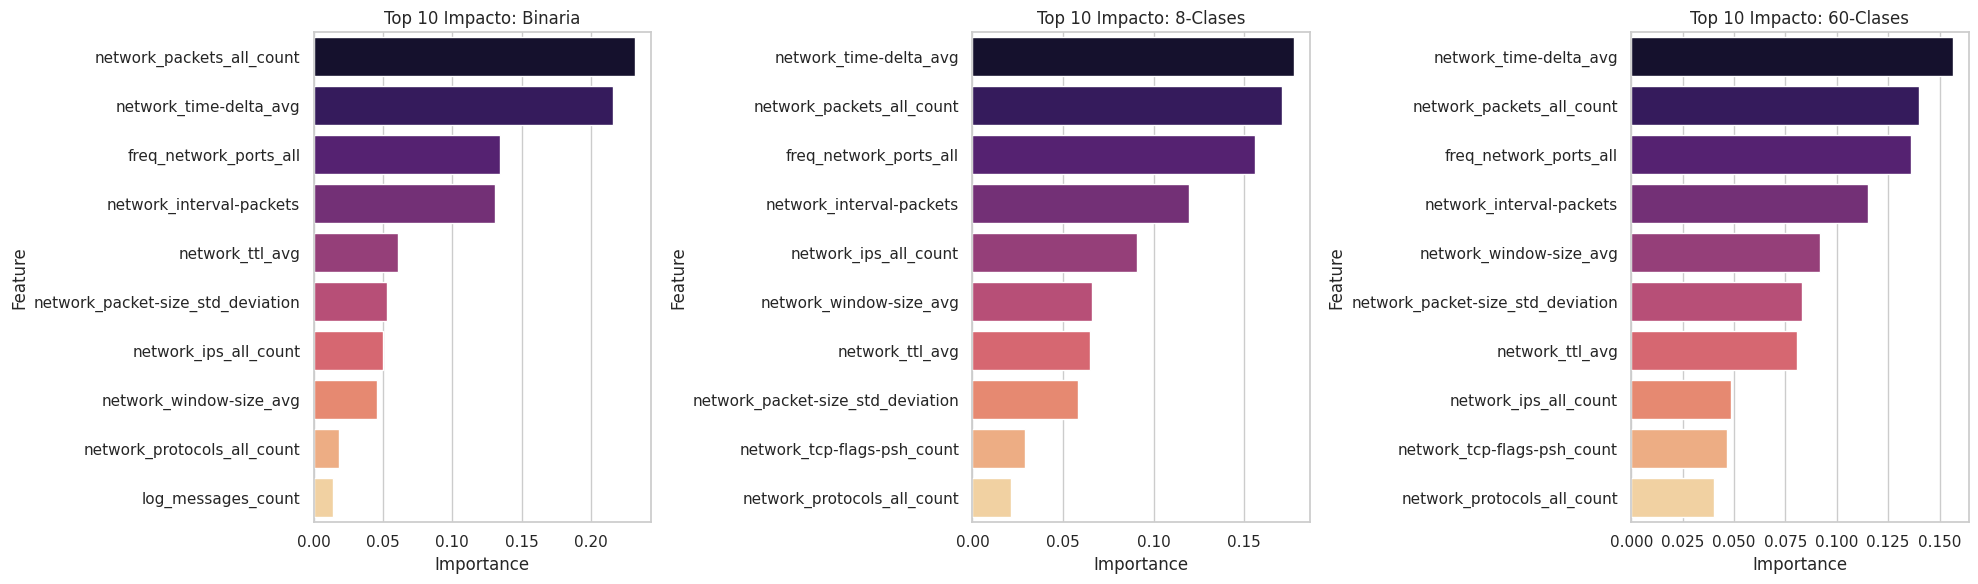

In [6]:
# 1. Reporte Detallado de Hiperparámetros de todos los modelos
print("=== RESUMEN DE HIPERPARÁMETROS POR MODELO ===")
configs = []
for t in tareas:
    for alg in algoritmos:
        if alg in modelos[t]:
            m = modelos[t][alg]
            # Extraemos los parámetros más relevantes para no saturar la vista
            p = m.get_params()
            interesantes = {k: v for k, v in p.items() if k in [
                'n_estimators', 'max_depth', 'n_neighbors', 'hidden_layer_sizes', 
                'activation', 'alpha', 'var_smoothing', 'weights'
            ]}
            configs.append({"Tarea": t, "Algoritmo": alg, "Params": interesantes})

df_params = pd.DataFrame(configs)
display(df_params, exclude=None)

# 2. Importancia de Variables (Específico para RandomForest)
# Nota: kNN y MLP no tienen un atributo directo de importancia tan claro como RF
print("\n=== IMPORTANCIA DE CARACTERÍSTICAS (Basado en RandomForest) ===")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model = "RandomForest"
for i, t in enumerate(tareas):
    if model in modelos[t]:
        rf = modelos[t][model]
        importancias = pd.DataFrame({
            'Feature': feature_names, 
            'Importance': rf.feature_importances_
        }).sort_values(by='Importance', ascending=False).head(10)
        
        sns.barplot(data=importancias, x='Importance', y='Feature', ax=axes[i], palette="magma")
        axes[i].set_title(f"Top 10 Impacto: {t}")
plt.tight_layout()
plt.show()

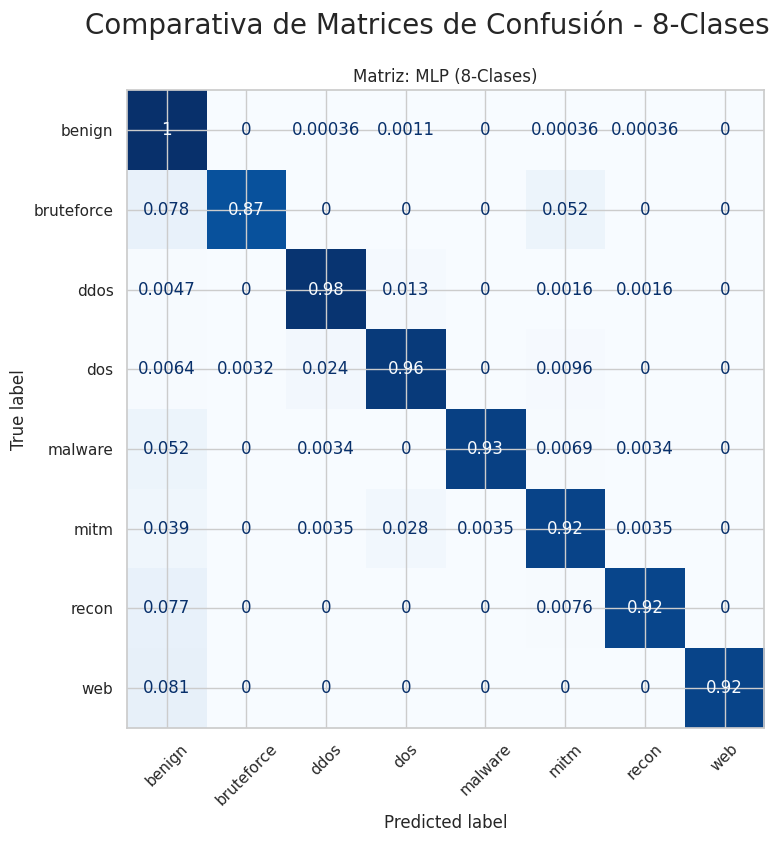

In [18]:
# --- SECCIÓN A MODIFICAR ---
algos_a_mostrar = ["MLP"] # Puedes poner uno o varios
# ---------------------------

t_eval = "8-Clases"
n_graficos = len(algos_a_mostrar)

# Configuración dinámica de la figura
if n_graficos == 1:
    fig, ax = plt.subplots(figsize=(10, 8))
    axes = [ax]  # Lo convertimos en lista para que el bucle funcione igual
else:
    cols = 2
    rows = (n_graficos + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 7 * rows))
    axes = axes.flatten()

X_eval_scaled = scalers[t_eval].transform(X_test_raw)
y_real = tareas[t_eval]["y_real"]

for i, alg in enumerate(algos_a_mostrar):
    if alg in modelos[t_eval]:
        y_pred = modelos[t_eval][alg].predict(X_eval_scaled)
        
        ConfusionMatrixDisplay.from_predictions(
            y_real, 
            y_pred, 
            cmap='Blues', 
            ax=axes[i], 
            xticks_rotation=45,
            colorbar=False,
            normalize='true',
            include_values=True,
            display_labels=tareas[t_eval]["classes"]
        )
        axes[i].set_title(f"Matriz: {alg} ({t_eval})")
    else:
        axes[i].set_title(f"Modelo {alg} no encontrado")
        axes[i].axis('off')

# Limpieza de ejes sobrantes (solo si n > 1)
if n_graficos > 1:
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.suptitle(f"Comparativa de Matrices de Confusión - {t_eval}", fontsize=20, y=1.05)
plt.savefig('pdfs/Matriz_confusion_MLP_8clases_sinbalan_10seg.pdf', format='pdf')
plt.show()

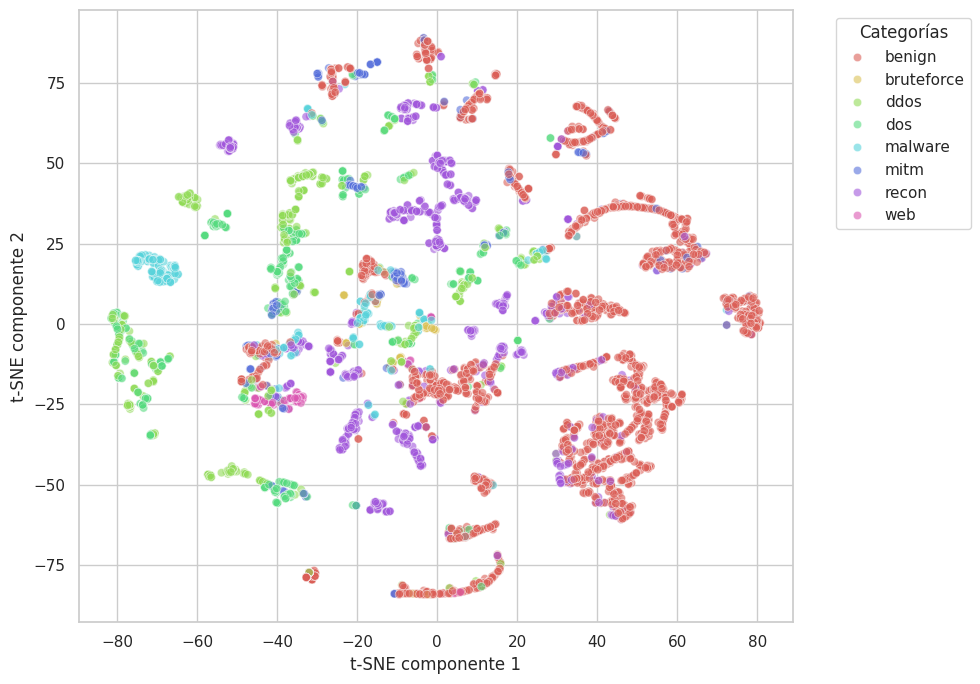

In [19]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

nombres_clases = ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X_test_scaled)

plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    x=X_embedded[:,0], 
    y=X_embedded[:,1],
    hue=y_test_8,
    palette=sns.color_palette("hls", 8),
    legend='full',
    alpha=0.6
)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, nombres_clases, title="Categorías", bbox_to_anchor=(1.05, 1), loc='upper left')

#plt.title("Diagrama TSNE de las clases sin balancear")
plt.xlabel("t-SNE componente 1")
plt.ylabel("t-SNE componente 2")
plt.tight_layout()
plt.savefig('pdfs/diagrama_TSNE_sinbalan.pdf', format='pdf')
plt.show()

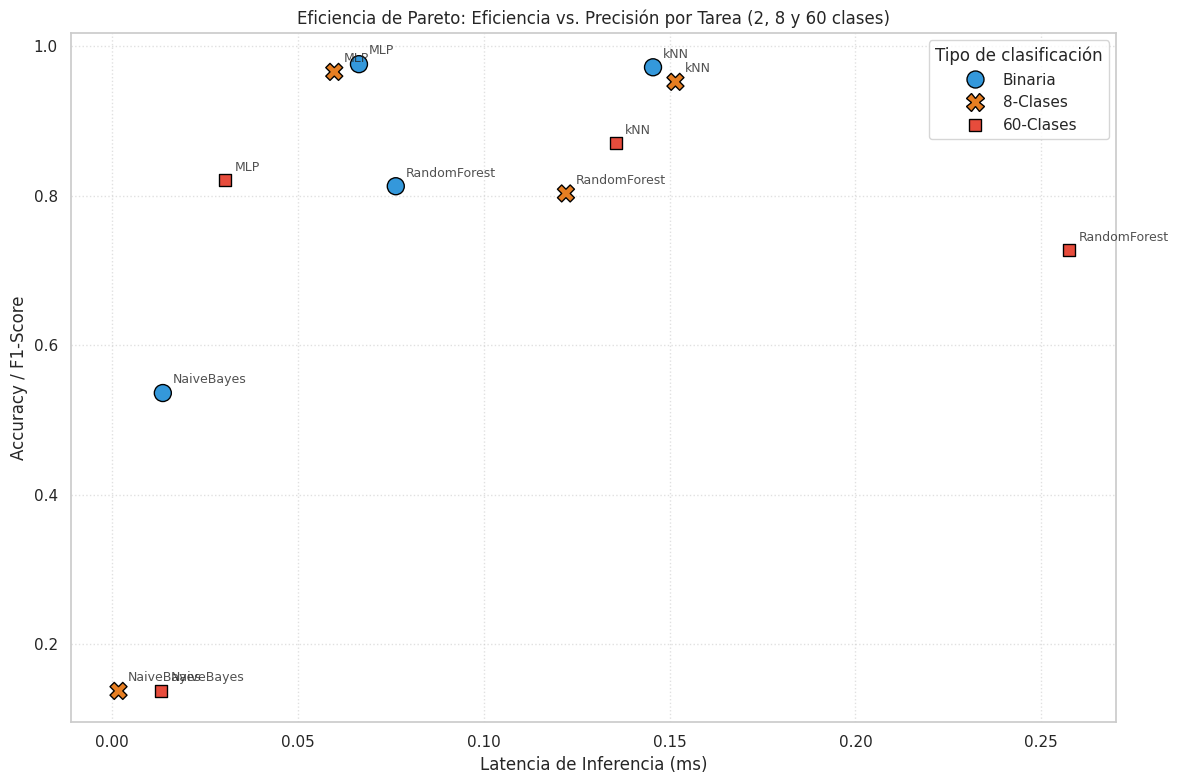

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Usamos una paleta de colores para diferenciar las tareas (2, 8, 60 clases)
palette = {'Binaria': '#3498db', '8-Clases': '#e67e22', '60-Clases': '#e74c3c'}

# Dibujamos los puntos diferenciados por la columna 'Tarea'
sns.scatterplot(
    data=df_comparativa, 
    x='Tiempo de test', 
    y='Accuracy', 
    hue='Tarea', 
    style='Tarea', 
    palette=palette, 
    s=150, 
    edgecolor='black'
)

# Añadimos las etiquetas de los algoritmos (RF, SVM, etc.)
for i in range(df_comparativa.shape[0]):
    plt.annotate(
        df_comparativa['Algoritmo'].iloc[i], 
        (df_comparativa['Tiempo de test'].iloc[i], df_comparativa['Accuracy'].iloc[i]),
        xytext=(7, 7), 
        textcoords='offset points',
        fontsize=9,
        alpha=0.8
    )

plt.title("Eficiencia de Pareto: Eficiencia vs. Precisión por Tarea (2, 8 y 60 clases)")
plt.xlabel("Latencia de Inferencia (ms)")
plt.ylabel("Accuracy / F1-Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Tipo de clasificación")
plt.tight_layout()
plt.show()